# Latent representation: pretrained variants against the baseline (axis-100-3000)

How does the latent representation of a variant differ from that of the baseline: its geometry, how much annotation information is linearly decodable from it, and how similar it is to the baseline representation on identical pixels? Stage shown: **pretrained**, i.e. the model right after the synthetic phases, evaluated on real data without any real-data training (0 real epochs); its head was trained with BCE on complete synthetic targets.

## Introduction

The thesis tested in parts 2-6 is that synthetic pretraining improves on the model trained on real data only.
Every table therefore contains the **real-only baseline** of the same axis (10 real epochs from the same
initialization) and every comparison is a **paired difference to that baseline**.

The ten pretraining variants differ only in the synthetic data seen before real data (campaign methodology,
`pretraining_campaign_methodology.md`):

| Variant | Synthetic phases | Construction |
| --- | --- | --- |
| P0 single bins | 1 x 10 epochs | ten spectra per axis bin; annotated bins carry their labels, blank bins are known negatives |
| P1 permutations | 1 x 10 epochs | component-token bag (30 per class and per blank bin) packed into mixed spectra |
| P2 joint / staged | 1 x 10 / 2 x 10 epochs | P0 and P1 rows shuffled together / P0 first, then P1 |
| P3 joint / staged | as P2 | P2 + overlap quota (30 extra tokens per class that shares a bin with another class in a training pixel) |
| P4 joint / staged | as P2 | P2 + rare quota (30 extra tokens per class of the least-annotated quarter) |
| P5 joint / staged | as P2 | P2 + both quotas |

Every variant yields three models along one lineage (stages): `pretrained`, `frozen_head` and `unfrozen_head`.
The staged schedules train twice as many synthetic epochs as the joint ones, so schedule and budget are
confounded (methodology, "Pretraining ablation").

### Assumptions

* **Pairing.** Repetition $r$ uses one initialization seed for the baseline and for every variant and stage
  (verified for all 310 models in the campaign-plan verification). The difference between a variant and the
  baseline of the same repetition removes the initialization effect; the five repetitions are the independent
  units. Pixels are not independent units and never enter a test as such.
* **Data.** Every model is evaluated on identical pixels: the same `train`, `test`, `test_extended` and
  `heldout_image` populations as in part 1, decoded once in the shared cache.
* **Objectives.** Synthetic phases: Masserstein (1.0) + BCE (0.2) on complete synthetic targets. Real phases
  (baseline and both fine-tuning stages): Masserstein (1.0) + VPU (0.2) + contractive (2e-3) + InfoNCE (1e-3,
  multilabel-Jaccard negatives, added by mistake and kept because every model used it).
* **Threshold metrics.** Precision, recall and F1 use $\hat Y \ge 0.5$, as in part 1. A head whose
  probabilities never reach 0.5 on real data has F1 = 0 although its ranking may still carry information;
  average precision is threshold free and is the primary head metric.
* **Uncertainty.** With five repetitions the Student-t interval has 4 degrees of freedom
  ($t_{0.975,4} = 2.78$); an interval that excludes zero is a strong statement, one that includes zero is not
  evidence of no effect.

### Notation

* $b_r$, $v_r$: value of a metric for the baseline and for a variant (at one stage) in repetition $r$.
* $s_m \in \{-1, +1\}$: direction of metric $m$; $-1$ for lower-is-better metrics (Masserstein $W_1$,
  spectral angle, MSE, Hamming loss, window contribution and within-window $W_1$, absolute mass imbalance, ECE,
  Brier score, true-label rank, false-positive rate and lift, losses), $+1$ otherwise.
* **Improvement** $\Delta_r = s_m (v_r - b_r)$: positive is always better than the baseline.
  **Relative improvement** $\Delta_r / |b_r|$.
* Summary over repetitions: mean $\bar\Delta$, SD $s$, interval $\bar\Delta \pm t_{0.975, n-1}\, s / \sqrt{n}$,
  and the numbers of repetitions with $\Delta_r > 0$ (`+k`) and $\Delta_r < 0$ (`-m`).
* Evaluations: `test` (withheld pixels of training images), `test_combined` (test + rare-class extension, the
  main per-class estimate), `heldout_image` (three images never seen; pooled), `heldout_image_per_image` (mean of
  the per-image values; pooled held-out values understate the ranking because annotations are incomplete across
  images, part 1_08).
* $W_1$: exact one-dimensional Wasserstein-1 distance between TIC-normalized input and reconstruction (m/z
  units); $u$: canonical latent code (LayerNorm affine removed).

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "stage_latent"
AXIS = "axis-100-3000"
STAGE = "pretrained"

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS, STAGE)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS, STAGE)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| stage:", STAGE, "| models:", metadata["models"] if isinstance(metadata["models"], int) else len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

BASELINE = "baseline"
VARIANTS = list(settings["variants"])
VARIANT_LABELS = {BASELINE: "real-only baseline", **{name: value["label"] for name, value in settings["variants"].items()}}
## The baseline keeps its catalog colour (the dark theme baseline colour is reserved for reference lines)
BASELINE_COLOR = next(value["visualization"]["color"] for value in settings["models"].values()
                      if value.get("select", {}).get("role") == settings["baseline_role"])
VARIANT_COLORS = {BASELINE: BASELINE_COLOR, **{name: value["color"] for name, value in settings["variants"].items()}}
STAGES = list(settings["stages"])
STAGE_LABELS = {"real_only": "real-only baseline", **{name: value["label"] for name, value in settings["stages"].items()}}
KEY_METRICS = settings["comparison"]["key_metrics"]
AXES = list(settings["axes"])
AXIS_LABELS = {name: value["label"] for name, value in settings["axes"].items()}
SHORT = {"masserstein": "W1", "spectral_angle": "spectral angle", "average_precision": "macro AP",
         "micro_average_precision": "micro AP", "f1": "macro F1 at 0.5"}
EVALUATION_NAMES = {**figures.DISPLAY_NAMES, "heldout_image_per_image": "held-out, per image"}


def key_panels(reconstruction=("test", "heldout_image"), prediction=("test_combined", "heldout_image_per_image")):
    """Forest-plot panels of the key metrics: (title, row selector)."""
    panels = []
    for spec in KEY_METRICS:
        for evaluation in (reconstruction if spec["family"] == "reconstruction" else prediction):
            selector = {"family": spec["family"], "metric": spec["metric"], "evaluation": evaluation,
                        "ranking": spec.get("ranking", "none")}
            panels.append((f"{SHORT.get(spec['metric'], spec['metric'])}, {EVALUATION_NAMES.get(evaluation, evaluation)}", selector))
    return panels


def interval(frame, digits=3):
    """'mean [ci_low, ci_high] (+k/-m)' strings of a summary table."""
    form = "{:." + str(digits) + "g}"
    return (frame["mean"].map(form.format) + " [" + frame.ci_low.map(form.format) + ", "
            + frame.ci_high.map(form.format) + "] (+" + frame.positive.astype(int).astype(str) + "/-"
            + frame.negative.astype(int).astype(str) + ")")

from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_comparison import summarize

ORDER = [BASELINE, *VARIANTS]
EVALUATIONS = ['test', 'test_combined', 'heldout_image', 'heldout_image_per_image']

geometry = table('geometry')
geometry_summary = table('geometry_improvements')
print('Probe:', metadata['probe'])

Analysis: stage_latent | axis: axis-100-3000 | stage: pretrained | models: 55
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'synthetic_reference': '6ba5bc1e0839ba0e', 'inference': '0243c1efb93b9c4c'}
Probe: {'train_size': 20000, 'regularization': 0.001}


## Producing the tables this notebook reads

### Methodology

#### Implementation

`stage_latent` runs the latent battery of part 1_06 on every model (parallel workers), fits a ridge probe of
the annotations on the canonical codes of a fixed training sample, evaluates it with the head's ranking
function, and compares every variant's codes with the baseline of the same repetition on identical pixels.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis stage_latent > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Absolute latent statistics of every variant and of the real-only baseline

### Methodology

#### Theoretical

The latent statistics and the linear-probe metrics of the baseline and of every variant, as levels: how much of
the latent is used and how well a linear read-out of the latent predicts the annotations.

#### Implementation

`geometry` (one value per model, population, representation space and statistic) and `probe` (ridge probe on the latent codes, same metrics as the head).

#### Figure descriptions

        Figure: linear-probe macro and micro AP on test + extension and on the held-out images. Tables: every geometry
        statistic per population and representation space; only the annotation neighbourhood agreement
        (`knn_annotation_jaccard`, higher = better) is coloured, the other statistics have no better direction.

Colours: in the figures the baseline is grey (its mean is the dashed line) and every other group is green when its
mean is better than the baseline mean and red when it is worse. In the tables every cell is mean +/- SD over the
repetitions; green / red cells are better / worse than the baseline cell of the same column (stronger colour = larger
difference within the column), the black frame marks the three best rows of the column and the grey bold row is the
real-only baseline.

In [3]:
LOWER_IS_BETTER = {'masserstein', 'spectral_angle', 'mse', 'hamming_loss', 'expected_calibration_error', 'brier_score',
                   'within', 'contribution', 'absolute_mass_imbalance', 'bic'}
METRIC_ORDER = ['average_precision', 'micro_average_precision', 'roc_auc', 'micro_roc_auc', 'ap_above_prevalence',
                'precision', 'recall', 'f1', 'micro_precision', 'micro_recall', 'micro_f1', 'micro_prevalence',
                'hamming_loss']
ABS_ORDER = [BASELINE, *VARIANTS]
LABELS_ABS = {**VARIANT_LABELS, **{name: VARIANT_LABELS.get(name, name) for name in ABS_ORDER}}


def better(metric):
    """Direction of a metric: 'lower' or 'higher' is better."""
    return 'lower' if metric in LOWER_IS_BETTER else 'higher'

heldout_image | u


metric,centroid_norm,collapsed,duplicate_pair_fraction,effective_dimension,effective_rank,knn_annotation_jaccard,label_correlation_p_value,label_correlation_pairs,label_correlation_spearman_r,norm_mean,norm_std,observed_mean_cos_theta,observed_sd_cos_theta,pair_cosine_median,pair_distance_median,participation_ratio,row_sum_abs_max,trace,two_nn_admissible,two_nn_intrinsic_dimension,uniform_baseline_sd_cos_theta
variant,,,,,,,,,,,,,,,,,,,,,
baseline,2.606 +/- 0.060,0.000 +/- 0.000,0.000 +/- 0.000,8.000 +/- 0.000,1.889 +/- 0.133,0.651 +/- 0.003,0.000 +/- 0.000,4997.000 +/- 0.000,0.486 +/- 0.003,3.162 +/- 0.000,0.000 +/- 0.000,0.673 +/- 0.032,0.355 +/- 0.038,0.882 +/- 0.011,1.537 +/- 0.075,1.360 +/- 0.066,0.000 +/- 0.000,3.207 +/- 0.311,1.000 +/- 0.000,5.584 +/- 0.111,0.333 +/- 0.000
P0_single,2.667 +/- 0.320,0.000 +/- 0.000,0.000 +/- 0.000,8.000 +/- 0.000,2.278 +/- 0.302,0.626 +/- 0.009,0.000 +/- 0.000,4997.000 +/- 0.000,0.434 +/- 0.042,3.162 +/- 0.000,0.000 +/- 0.000,0.715 +/- 0.159,0.261 +/- 0.139,0.842 +/- 0.084,1.719 +/- 0.494,1.546 +/- 0.163,0.000 +/- 0.000,2.806 +/- 1.594,1.000 +/- 0.000,6.015 +/- 0.289,0.333 +/- 0.000
P1_permutation,3.084 +/- 0.005,0.000 +/- 0.000,0.000 +/- 0.000,8.000 +/- 0.000,1.373 +/- 0.033,0.572 +/- 0.016,0.000 +/- 0.000,4997.000 +/- 0.000,0.457 +/- 0.006,3.162 +/- 0.000,0.000 +/- 0.000,0.950 +/- 0.003,0.059 +/- 0.003,0.982 +/- 0.001,0.603 +/- 0.022,1.167 +/- 0.014,0.000 +/- 0.000,0.491 +/- 0.033,1.000 +/- 0.000,4.943 +/- 0.118,0.333 +/- 0.000
P2_joint_base,3.093 +/- 0.012,0.000 +/- 0.000,0.000 +/- 0.000,8.000 +/- 0.000,1.403 +/- 0.094,0.594 +/- 0.008,0.000 +/- 0.000,4997.000 +/- 0.000,0.480 +/- 0.008,3.162 +/- 0.000,0.000 +/- 0.000,0.955 +/- 0.008,0.056 +/- 0.009,0.986 +/- 0.003,0.522 +/- 0.058,1.154 +/- 0.044,0.000 +/- 0.000,0.436 +/- 0.075,1.000 +/- 0.000,5.463 +/- 0.196,0.333 +/- 0.000
P2_staged_base,3.032 +/- 0.032,0.000 +/- 0.000,0.000 +/- 0.000,8.000 +/- 0.000,1.666 +/- 0.363,0.607 +/- 0.020,0.000 +/- 0.000,4997.000 +/- 0.000,0.475 +/- 0.009,3.162 +/- 0.000,0.000 +/- 0.000,0.918 +/- 0.020,0.094 +/- 0.025,0.969 +/- 0.006,0.781 +/- 0.080,1.279 +/- 0.193,0.000 +/- 0.000,0.808 +/- 0.191,1.000 +/- 0.000,5.635 +/- 0.212,0.333 +/- 0.000
P3_joint_overlap,3.075 +/- 0.019,0.000 +/- 0.000,0.000 +/- 0.000,8.000 +/- 0.000,1.429 +/- 0.078,0.581 +/- 0.012,0.000 +/- 0.000,4997.000 +/- 0.000,0.482 +/- 0.007,3.162 +/- 0.000,0.000 +/- 0.000,0.944 +/- 0.012,0.068 +/- 0.014,0.983 +/- 0.004,0.587 +/- 0.068,1.176 +/- 0.039,0.000 +/- 0.000,0.544 +/- 0.120,1.000 +/- 0.000,5.214 +/- 0.175,0.333 +/- 0.000
P3_staged_overlap,3.031 +/- 0.031,0.000 +/- 0.000,0.000 +/- 0.000,8.000 +/- 0.000,1.687 +/- 0.225,0.608 +/- 0.019,0.000 +/- 0.000,4997.000 +/- 0.000,0.475 +/- 0.017,3.162 +/- 0.000,0.000 +/- 0.000,0.917 +/- 0.019,0.092 +/- 0.023,0.967 +/- 0.007,0.809 +/- 0.080,1.280 +/- 0.101,0.000 +/- 0.000,0.812 +/- 0.189,1.000 +/- 0.000,5.563 +/- 0.247,0.333 +/- 0.000
P4_joint_rare,3.069 +/- 0.007,0.000 +/- 0.000,0.000 +/- 0.000,8.000 +/- 0.000,1.405 +/- 0.009,0.585 +/- 0.009,0.000 +/- 0.000,4997.000 +/- 0.000,0.475 +/- 0.005,3.162 +/- 0.000,0.000 +/- 0.000,0.941 +/- 0.004,0.071 +/- 0.004,0.982 +/- 0.002,0.603 +/- 0.036,1.163 +/- 0.008,0.000 +/- 0.000,0.579 +/- 0.040,1.000 +/- 0.000,5.364 +/- 0.198,0.333 +/- 0.000
P4_staged_rare,3.030 +/- 0.039,0.000 +/- 0.000,0.000 +/- 0.000,8.000 +/- 0.000,1.573 +/- 0.131,0.608 +/- 0.010,0.000 +/- 0.000,4997.000 +/- 0.000,0.480 +/- 0.010,3.162 +/- 0.000,0.000 +/- 0.000,0.917 +/- 0.024,0.097 +/- 0.027,0.969 +/- 0.010,0.782 +/- 0.127,1.225 +/- 0.062,0.000 +/- 0.000,0.815 +/- 0.234,1.000 +/- 0.000,5.698 +/- 0.183,0.333 +/- 0.000


heldout_image | z


metric,centroid_norm,collapsed,duplicate_pair_fraction,effective_rank,knn_annotation_jaccard,norm_mean,norm_std,pair_cosine_median,pair_distance_median,participation_ratio,row_sum_abs_max,trace
variant,,,,,,,,,,,,
baseline,2.611 +/- 0.081,0.000 +/- 0.000,0.000 +/- 0.000,1.904 +/- 0.144,0.652 +/- 0.003,3.185 +/- 0.025,0.027 +/- 0.009,0.878 +/- 0.012,1.572 +/- 0.086,1.368 +/- 0.072,0.379 +/- 0.190,3.323 +/- 0.385
P0_single,2.608 +/- 0.667,0.000 +/- 0.000,0.000 +/- 0.000,2.294 +/- 0.310,0.625 +/- 0.010,3.047 +/- 0.515,0.036 +/- 0.035,0.844 +/- 0.090,1.588 +/- 0.354,1.554 +/- 0.168,0.349 +/- 0.291,2.343 +/- 0.899
P1_permutation,3.089 +/- 0.019,0.000 +/- 0.000,0.000 +/- 0.000,1.375 +/- 0.040,0.572 +/- 0.016,3.169 +/- 0.017,0.010 +/- 0.005,0.981 +/- 0.001,0.612 +/- 0.022,1.168 +/- 0.018,0.104 +/- 0.064,0.504 +/- 0.035
P2_joint_base,2.913 +/- 0.129,0.000 +/- 0.000,0.000 +/- 0.000,1.416 +/- 0.100,0.594 +/- 0.008,2.988 +/- 0.122,0.024 +/- 0.015,0.984 +/- 0.004,0.525 +/- 0.048,1.160 +/- 0.048,0.175 +/- 0.046,0.440 +/- 0.069
P2_staged_base,2.888 +/- 0.475,0.000 +/- 0.000,0.000 +/- 0.000,1.661 +/- 0.350,0.607 +/- 0.020,3.013 +/- 0.508,0.031 +/- 0.014,0.969 +/- 0.006,0.739 +/- 0.129,1.275 +/- 0.183,0.317 +/- 0.286,0.763 +/- 0.338
P3_joint_overlap,2.921 +/- 0.052,0.000 +/- 0.000,0.000 +/- 0.000,1.428 +/- 0.079,0.581 +/- 0.013,3.019 +/- 0.042,0.027 +/- 0.013,0.980 +/- 0.004,0.606 +/- 0.065,1.175 +/- 0.038,0.247 +/- 0.112,0.585 +/- 0.124
P3_staged_overlap,2.811 +/- 0.543,0.000 +/- 0.000,0.000 +/- 0.000,1.689 +/- 0.226,0.608 +/- 0.019,2.940 +/- 0.586,0.031 +/- 0.012,0.966 +/- 0.006,0.774 +/- 0.202,1.280 +/- 0.100,0.340 +/- 0.266,0.781 +/- 0.391
P4_joint_rare,2.866 +/- 0.111,0.000 +/- 0.000,0.000 +/- 0.000,1.407 +/- 0.023,0.585 +/- 0.009,2.964 +/- 0.110,0.041 +/- 0.027,0.979 +/- 0.002,0.600 +/- 0.022,1.165 +/- 0.018,0.277 +/- 0.096,0.575 +/- 0.021
P4_staged_rare,2.893 +/- 0.417,0.000 +/- 0.000,0.000 +/- 0.000,1.561 +/- 0.116,0.608 +/- 0.010,3.022 +/- 0.455,0.017 +/- 0.008,0.969 +/- 0.011,0.748 +/- 0.215,1.219 +/- 0.053,0.321 +/- 0.320,0.787 +/- 0.438


test | u


metric,centroid_norm,collapsed,duplicate_pair_fraction,effective_dimension,effective_rank,knn_annotation_jaccard,label_correlation_p_value,label_correlation_pairs,label_correlation_spearman_r,norm_mean,norm_std,observed_mean_cos_theta,observed_sd_cos_theta,pair_cosine_median,pair_distance_median,participation_ratio,row_sum_abs_max,trace,two_nn_admissible,two_nn_intrinsic_dimension,uniform_baseline_sd_cos_theta
variant,,,,,,,,,,,,,,,,,,,,,
baseline,2.016 +/- 0.073,0.000 +/- 0.000,0.000 +/- 0.000,8.000 +/- 0.000,5.097 +/- 0.164,0.534 +/- 0.003,0.000 +/- 0.000,4997.000 +/- 0.000,0.385 +/- 0.013,3.162 +/- 0.000,0.000 +/- 0.000,0.419 +/- 0.029,0.344 +/- 0.013,0.371 +/- 0.035,3.546 +/- 0.099,3.912 +/- 0.141,0.000 +/- 0.000,5.933 +/- 0.293,1.000 +/- 0.000,5.248 +/- 0.109,0.333 +/- 0.000
P0_single,2.215 +/- 0.285,0.000 +/- 0.000,0.000 +/- 0.000,8.000 +/- 0.000,4.322 +/- 0.809,0.508 +/- 0.008,0.000 +/- 0.000,4997.000 +/- 0.000,0.429 +/- 0.083,3.162 +/- 0.000,0.000 +/- 0.000,0.505 +/- 0.124,0.333 +/- 0.104,0.530 +/- 0.103,3.051 +/- 0.351,3.097 +/- 0.665,0.000 +/- 0.000,5.027 +/- 1.274,1.000 +/- 0.000,5.500 +/- 0.090,0.333 +/- 0.000
P1_permutation,3.076 +/- 0.011,0.000 +/- 0.000,0.000 +/- 0.000,8.000 +/- 0.000,2.148 +/- 0.257,0.457 +/- 0.011,0.000 +/- 0.000,4997.000 +/- 0.000,0.385 +/- 0.044,3.162 +/- 0.000,0.000 +/- 0.000,0.947 +/- 0.007,0.055 +/- 0.006,0.963 +/- 0.006,0.854 +/- 0.074,1.611 +/- 0.155,0.000 +/- 0.000,0.536 +/- 0.067,1.000 +/- 0.000,4.441 +/- 0.228,0.333 +/- 0.000
P2_joint_base,3.050 +/- 0.035,0.000 +/- 0.000,0.000 +/- 0.000,8.000 +/- 0.000,2.394 +/- 0.121,0.489 +/- 0.002,0.000 +/- 0.000,4997.000 +/- 0.000,0.387 +/- 0.032,3.162 +/- 0.000,0.000 +/- 0.000,0.932 +/- 0.021,0.065 +/- 0.018,0.950 +/- 0.017,0.992 +/- 0.168,1.684 +/- 0.066,0.000 +/- 0.000,0.696 +/- 0.212,1.000 +/- 0.000,4.746 +/- 0.093,0.333 +/- 0.000
P2_staged_base,2.948 +/- 0.054,0.000 +/- 0.000,0.000 +/- 0.000,8.000 +/- 0.000,2.658 +/- 0.323,0.493 +/- 0.008,0.000 +/- 0.000,4997.000 +/- 0.000,0.424 +/- 0.052,3.162 +/- 0.000,0.000 +/- 0.000,0.871 +/- 0.032,0.114 +/- 0.028,0.894 +/- 0.029,1.442 +/- 0.217,1.896 +/- 0.191,0.000 +/- 0.000,1.305 +/- 0.321,1.000 +/- 0.000,5.168 +/- 0.274,0.333 +/- 0.000
P3_joint_overlap,3.056 +/- 0.022,0.000 +/- 0.000,0.000 +/- 0.000,8.000 +/- 0.000,2.361 +/- 0.206,0.486 +/- 0.006,0.000 +/- 0.000,4997.000 +/- 0.000,0.401 +/- 0.026,3.162 +/- 0.000,0.000 +/- 0.000,0.935 +/- 0.013,0.063 +/- 0.012,0.952 +/- 0.011,0.973 +/- 0.112,1.679 +/- 0.142,0.000 +/- 0.000,0.663 +/- 0.132,1.000 +/- 0.000,4.607 +/- 0.153,0.333 +/- 0.000
P3_staged_overlap,2.920 +/- 0.077,0.000 +/- 0.000,0.000 +/- 0.000,8.000 +/- 0.000,2.646 +/- 0.235,0.493 +/- 0.008,0.000 +/- 0.000,4997.000 +/- 0.000,0.440 +/- 0.035,3.162 +/- 0.000,0.000 +/- 0.000,0.855 +/- 0.044,0.127 +/- 0.039,0.886 +/- 0.035,1.493 +/- 0.255,1.920 +/- 0.152,0.000 +/- 0.000,1.469 +/- 0.451,1.000 +/- 0.000,5.087 +/- 0.152,0.333 +/- 0.000
P4_joint_rare,3.047 +/- 0.023,0.000 +/- 0.000,0.000 +/- 0.000,8.000 +/- 0.000,2.329 +/- 0.088,0.485 +/- 0.004,0.000 +/- 0.000,4997.000 +/- 0.000,0.397 +/- 0.049,3.162 +/- 0.000,0.000 +/- 0.000,0.930 +/- 0.013,0.067 +/- 0.011,0.949 +/- 0.011,1.006 +/- 0.101,1.648 +/- 0.065,0.000 +/- 0.000,0.714 +/- 0.139,1.000 +/- 0.000,4.735 +/- 0.176,0.333 +/- 0.000
P4_staged_rare,2.833 +/- 0.092,0.000 +/- 0.000,0.000 +/- 0.000,8.000 +/- 0.000,2.561 +/- 0.443,0.492 +/- 0.010,0.000 +/- 0.000,4997.000 +/- 0.000,0.414 +/- 0.023,3.162 +/- 0.000,0.000 +/- 0.000,0.806 +/- 0.052,0.176 +/- 0.059,0.843 +/- 0.031,1.764 +/- 0.172,1.914 +/- 0.393,0.000 +/- 0.000,1.965 +/- 0.526,1.000 +/- 0.000,5.128 +/- 0.228,0.333 +/- 0.000


test | z


metric,centroid_norm,collapsed,duplicate_pair_fraction,effective_rank,knn_annotation_jaccard,norm_mean,norm_std,pair_cosine_median,pair_distance_median,participation_ratio,row_sum_abs_max,trace
variant,,,,,,,,,,,,
baseline,1.987 +/- 0.055,0.000 +/- 0.000,0.000 +/- 0.000,5.109 +/- 0.167,0.535 +/- 0.003,3.190 +/- 0.045,0.041 +/- 0.014,0.348 +/- 0.036,3.637 +/- 0.146,3.936 +/- 0.140,0.406 +/- 0.187,6.232 +/- 0.465
P0_single,2.146 +/- 0.536,0.000 +/- 0.000,0.000 +/- 0.000,4.321 +/- 0.816,0.508 +/- 0.008,3.033 +/- 0.528,0.056 +/- 0.036,0.529 +/- 0.113,2.898 +/- 0.490,3.106 +/- 0.676,0.376 +/- 0.307,4.592 +/- 1.774
P1_permutation,3.085 +/- 0.021,0.000 +/- 0.000,0.000 +/- 0.000,2.142 +/- 0.257,0.456 +/- 0.011,3.173 +/- 0.017,0.010 +/- 0.003,0.963 +/- 0.007,0.866 +/- 0.079,1.609 +/- 0.157,0.109 +/- 0.065,0.550 +/- 0.073
P2_joint_base,2.881 +/- 0.146,0.000 +/- 0.000,0.000 +/- 0.000,2.430 +/- 0.124,0.489 +/- 0.002,3.002 +/- 0.117,0.033 +/- 0.015,0.942 +/- 0.022,1.005 +/- 0.157,1.713 +/- 0.084,0.197 +/- 0.051,0.704 +/- 0.190
P2_staged_base,2.816 +/- 0.480,0.000 +/- 0.000,0.000 +/- 0.000,2.659 +/- 0.306,0.492 +/- 0.008,3.020 +/- 0.538,0.042 +/- 0.018,0.895 +/- 0.030,1.382 +/- 0.377,1.894 +/- 0.175,0.343 +/- 0.289,1.234 +/- 0.595
P3_joint_overlap,2.914 +/- 0.064,0.000 +/- 0.000,0.000 +/- 0.000,2.352 +/- 0.222,0.486 +/- 0.006,3.033 +/- 0.051,0.030 +/- 0.010,0.945 +/- 0.013,1.003 +/- 0.110,1.670 +/- 0.145,0.268 +/- 0.115,0.710 +/- 0.141
P3_staged_overlap,2.717 +/- 0.531,0.000 +/- 0.000,0.000 +/- 0.000,2.658 +/- 0.244,0.492 +/- 0.008,2.950 +/- 0.599,0.034 +/- 0.010,0.883 +/- 0.033,1.429 +/- 0.417,1.932 +/- 0.162,0.374 +/- 0.268,1.386 +/- 0.713
P4_joint_rare,2.858 +/- 0.069,0.000 +/- 0.000,0.000 +/- 0.000,2.324 +/- 0.140,0.485 +/- 0.004,2.980 +/- 0.079,0.045 +/- 0.023,0.943 +/- 0.011,1.007 +/- 0.109,1.648 +/- 0.103,0.305 +/- 0.101,0.718 +/- 0.148
P4_staged_rare,2.695 +/- 0.365,0.000 +/- 0.000,0.000 +/- 0.000,2.542 +/- 0.456,0.491 +/- 0.011,3.018 +/- 0.486,0.043 +/- 0.025,0.843 +/- 0.039,1.692 +/- 0.434,1.898 +/- 0.403,0.367 +/- 0.325,1.931 +/- 1.015


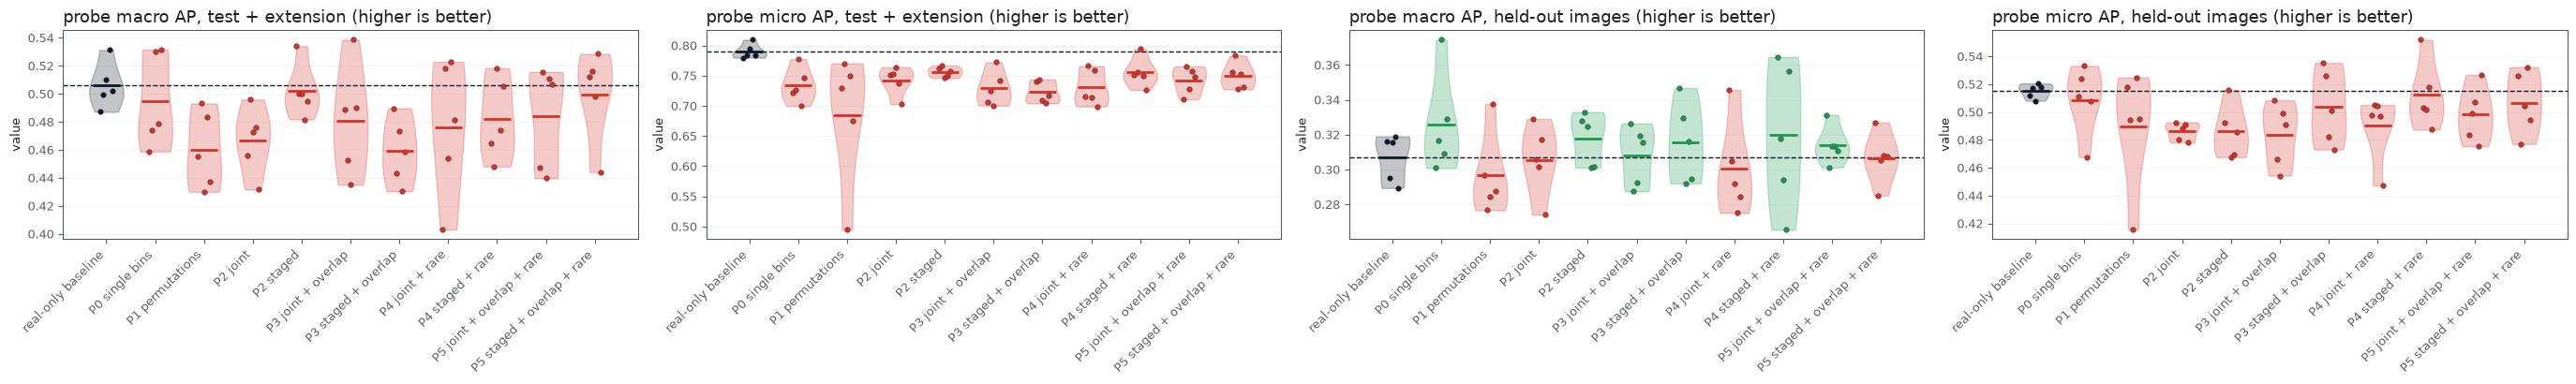

In [4]:
probe_abs = table('probe')
probe_abs = probe_abs[probe_abs.scope == 'train_supported']
panels = [(f"probe {SHORT.get(metric, metric)}, {EVALUATION_NAMES.get(evaluation, evaluation)}", {'metric': metric, 'evaluation': evaluation}, 'higher')
          for evaluation in ('test_combined', 'heldout_image') for metric in ('average_precision', 'micro_average_precision')]
figures.metric_panels(probe_abs, panels=panels, group='variant', order=ABS_ORDER, labels=LABELS_ABS, baseline=BASELINE, columns=4, theme=theme);
geometry_abs = table('geometry')
for (population, space), rows in geometry_abs.groupby(['population', 'space']):
    print(population, '|', space)
    display(figures.comparison_table(rows, index='variant', columns='metric', baseline=BASELINE, order=ABS_ORDER,
                                     direction={'knn_annotation_jaccard': 'higher'}))

### Remarks

- linear probe macro AP, test_combined: baseline 0.506; others 0.459-0.5022; 0 of 10 better than the baseline; best P2 staged (0.5022), worst P3 staged + overlap (0.459).
- linear probe macro AP, heldout_image: baseline 0.3071; others 0.2966-0.3259; 6 of 10 better than the baseline; best P0 single bins (0.3259), worst P1 permutations (0.2966).
- effective_rank, held-out: baseline 1.904; others 1.375-2.294; 1 of 10 better than the baseline; best P0 single bins (2.294), worst P1 permutations (1.375).
- knn_annotation_jaccard, held-out: baseline 0.6515; others 0.5723-0.6254; 0 of 10 better than the baseline; best P0 single bins (0.6254), worst P1 permutations (0.5723).

### Notes

## Geometry of the canonical codes against the baseline

### Methodology

#### Theoretical

        Battery of part 1_06 on the canonical codes $u$: effective rank and participation ratio of the covariance
        spectrum (how many directions are used), TwoNN intrinsic dimension, mean pairwise $\cos\theta$ spread,
        neighbourhood annotation agreement (Jaccard of the annotations of $k$ nearest neighbours) and the
        correlation between latent distance and annotation distance.

For latent-geometry quantities (effective rank, participation ratio, TwoNN dimension, neighbourhood label
agreement, ...) there is no better direction; their "improvement" is the plain difference $v_r - b_r$.

#### Implementation

`geometry_improvements` (paired, space $u$) and `geometry` (values).

#### Figure descriptions

Forest plot: one panel per quantity and population (rows = variants); the dashed line is the baseline value.
The table gives repetition means of the values (baseline first).

population         heldout_image                                                                                                                                    test                         \
metric            effective_rank knn_annotation_jaccard label_correlation_spearman_r observed_sd_cos_theta participation_ratio two_nn_intrinsic_dimension effective_rank knn_annotation_jaccard   
variant                                                                                                                                                                                           
baseline                   1.889                  0.651                        0.486                 0.355               1.360                      5.584          5.097                  0.534   
P0_single                  2.278                  0.626                        0.434                 0.261               1.546                      6.015          4.322                  0.508   
P1_permutation             1.373                  0.572                        0.457                 0.059               1.167                      4.943          2.148                  0.457   
P2_joint_base              1.403                  0.594                        0.480                 0.056               1.154                      5.463          2.394                  0.489   
P2_staged_base             1.666                  0.607                        0.475                 0.094               1.279                      5.635          2.658                  0.493   
P3_joint_overlap           1.429                  0.581                        0.482                 0.068               1.176                      5.214          2.361                  0.486   
P3_staged_overlap          1.687                  0.608                        0.475                 0.092               1.280                      5.563          2.646                  0.493   
P4_joint_rare              1.405                  0.585                        0.475                 0.071               1.163                      5.364          2.329                  0.485   
P4_staged_rare             1.573                  0.608                        0.480                 0.097               1.225                      5.698          2.561                  0.492   
P5_joint_all               1.398                  0.593                        0.478                 0.071               1.157                      5.354          2.345                  0.485   
P5_staged_all              1.513                  0.600                        0.472                 0.100               1.201                      5.493          2.613                  0.490   

population                                                                                                           
metric            label_correlation_spearman_r observed_sd_cos_theta participation_ratio two_nn_intrinsic_dimension  
variant                                                                                                              
baseline                                 0.385                 0.344               3.912                      5.248  
P0_single                                0.429                 0.333               3.097                      5.500  
P1_permutation                           0.385                 0.055               1.611                      4.441  
P2_joint_base                            0.387                 0.065               1.684                      4.746  
P2_staged_base                           0.424                 0.114               1.896                      5.168  
P3_joint_overlap                         0.401                 0.063               1.679                      4.607  
P3_staged_overlap                        0.440                 0.127               1.920                      5.087  
P4_joint_rare                            0.397                 0.067               1.648 

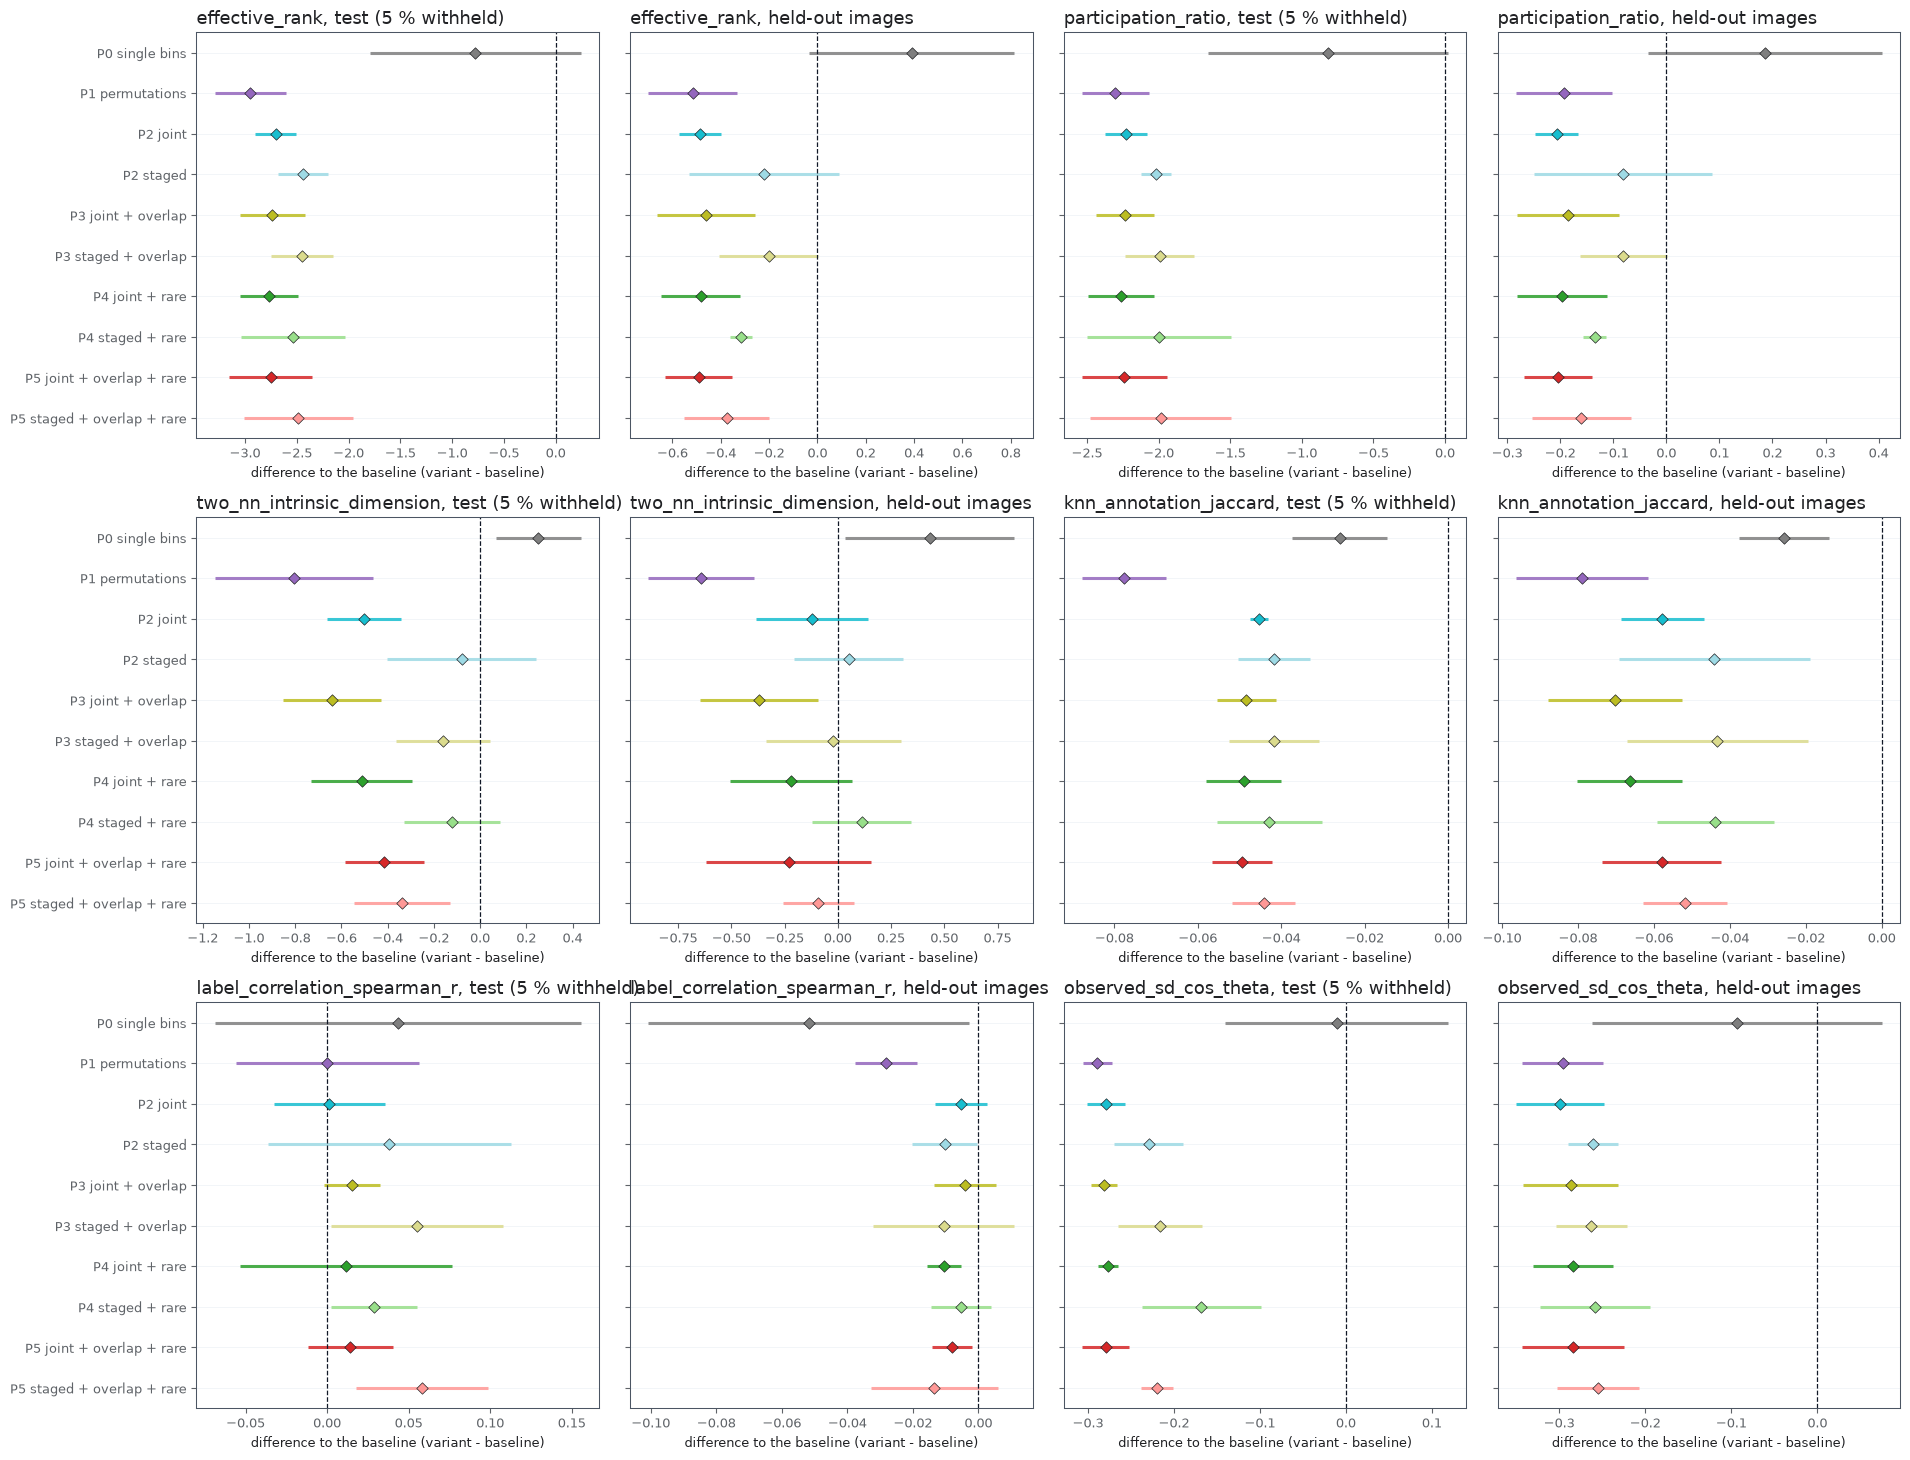

In [5]:
QUANTITIES = ['effective_rank', 'participation_ratio', 'two_nn_intrinsic_dimension', 'knn_annotation_jaccard',
              'label_correlation_spearman_r', 'observed_sd_cos_theta']
panels = [(f'{quantity}, {EVALUATION_NAMES[population]}', {'metric': quantity, 'population': population})
          for quantity in QUANTITIES for population in ['test', 'heldout_image']]
figures.improvement_forest(geometry_summary, panels=panels, variants=VARIANTS, labels=VARIANT_LABELS, colors=VARIANT_COLORS,
                           columns=4, xlabel='difference to the baseline (variant - baseline)', theme=theme);
values = geometry[(geometry.space == 'u') & geometry.metric.isin(QUANTITIES)]
display(values.groupby(['variant', 'population', 'metric']).value.mean().unstack(['population', 'metric']).reindex(ORDER).round(3))

### Remarks

- effective_rank (test): baseline 5.1, variants 2.15-4.32; significantly higher: 0, lower: 9 of 10 variants.
- participation_ratio (test): baseline 3.91, variants 1.61-3.1; significantly higher: 0, lower: 9 of 10 variants.
- two_nn_intrinsic_dimension (test): baseline 5.25, variants 4.44-5.5; significantly higher: 1, lower: 6 of 10 variants.
- knn_annotation_jaccard (test): baseline 0.534, variants 0.457-0.508; significantly higher: 0, lower: 10 of 10 variants.

### Notes

## Similarity to the baseline representation

### Methodology

#### Theoretical

On identical pixels the codes of a variant $U^{v}$ and of the baseline $U^{b}$ of the same repetition are
compared by linear CKA (1 = identical up to rotation and isotropic scaling), the orthogonal Procrustes
distance after centring and scaling, the overlap of $k$-nearest-neighbour sets and trustworthiness /
continuity (neighbourhood preservation in both directions).

#### Implementation

`to_baseline` (`pairwise_geometry_battery` on the latent sample of part 1).

#### Figure descriptions

One panel per quantity; x = variant, colour = population, one point per repetition.

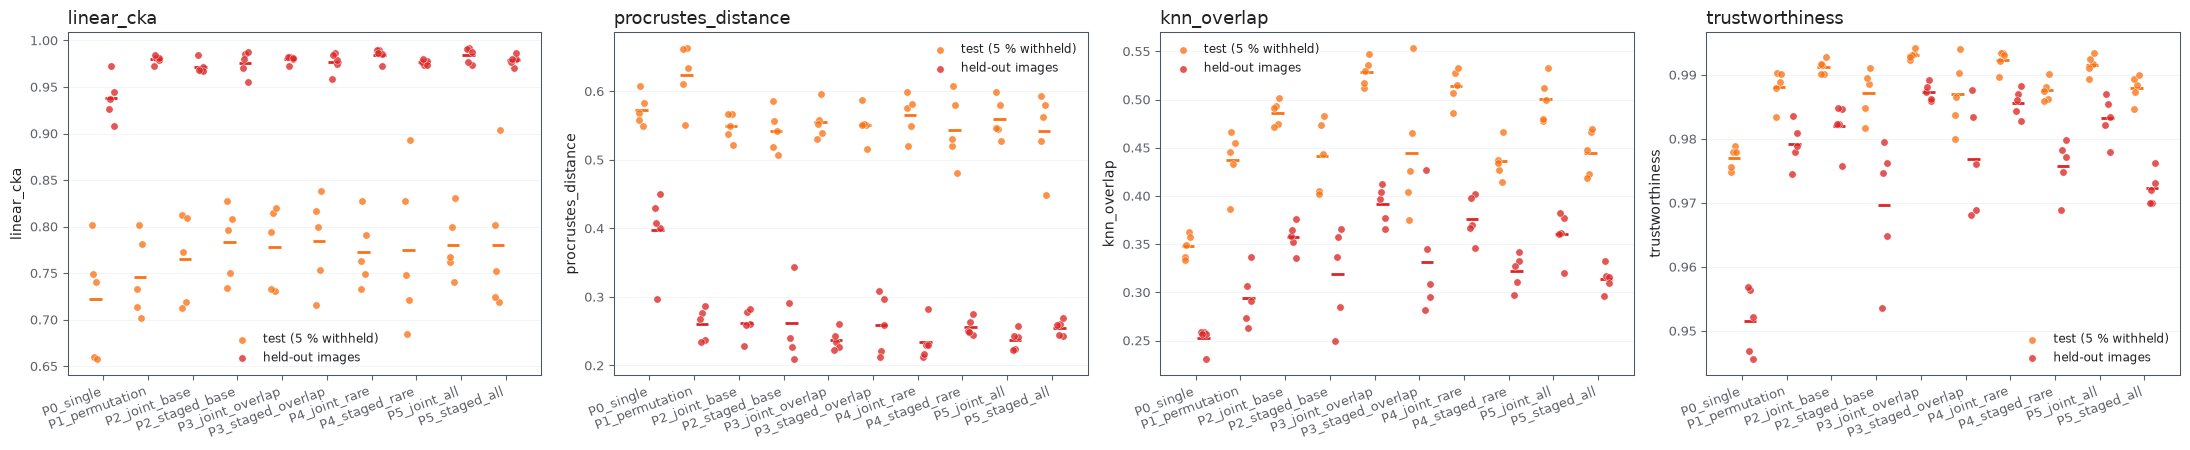

In [6]:
similarity = table('to_baseline')
figure, axes = plt.subplots(1, 4, figsize=(22, 4.6), dpi=theme.figure_dpi)
for ax, quantity in zip(axes, ['linear_cka', 'procrustes_distance', 'knn_overlap', 'trustworthiness']):
    figures.repetition_points(similarity, value=quantity, group='variant', hue='population', order=VARIANTS,
                              hue_order=['test', 'heldout_image'], colors=POPULATION_COLORS, ylabel=quantity, title=quantity, ax=ax, theme=theme)
figure.tight_layout()

### Remarks

- held-out: linear CKA to the baseline 0.908-0.992 (mean 0.975); k-NN overlap 0.23-0.427.
- test: linear CKA to the baseline 0.657-0.903 (mean 0.769); k-NN overlap 0.333-0.554.

### Notes

## Linearly decodable annotation information: probe against head

### Methodology

#### Theoretical

A ridge probe $\hat Y = [u, 1] W$ is fitted per model on a fixed sample of training pixels (the same pixels
for every model) and evaluated like the head (annotation retrieval, training-supported classes). The probe
AP measures what a linear read-out of the representation can decode; probe minus head AP shows whether the
model's own head uses that information (negative: the head is better than a linear read-out; positive: the
head loses decodable information, e.g. a frozen synthetic head).

#### Implementation

`probe` (probe ranking metrics) and `probe_versus_head` (per model, probe minus head).

#### Figure descriptions

First row: probe macro AP per variant; second row: probe minus head macro AP; columns = evaluations. The table
gives repetition means of probe AP, head AP and their difference.

value_probe                  value_head               probe_minus_head              
evaluation        heldout_image test_combined heldout_image test_combined    heldout_image test_combined
variant                                                                                                 
baseline                 0.3071        0.5060        0.3761        0.7084          -0.0690       -0.2024
P0_single                0.3259        0.4946        0.2488        0.0706           0.0771        0.4240
P1_permutation           0.2966        0.4599        0.2627        0.1444           0.0339        0.3154
P2_joint_base            0.3056        0.4665        0.2492        0.0646           0.0564        0.4019
P2_staged_base           0.3176        0.5022        0.2423        0.0545           0.0754        0.4476
P3_joint_overlap         0.3082        0.4810        0.2587        0.0572           0.0495        0.4238
P3_staged_overlap        0.3158        0.4590        0.2381        0.0564           0.0777        0.4026
P4_joint_rare            0.3003        0.4760        0.2498        0.0567           0.0506        0.4193
P4_staged_rare           0.3197        0.4821        0.2540        0.0544           0.0656        0.4277
P5_joint_all             0.3140        0.4841        0.2537        0.0565           0.0603        0.4277
P5_staged_all            0.3065        0.4998        0.2448        0.0583           0.0618        0.4415

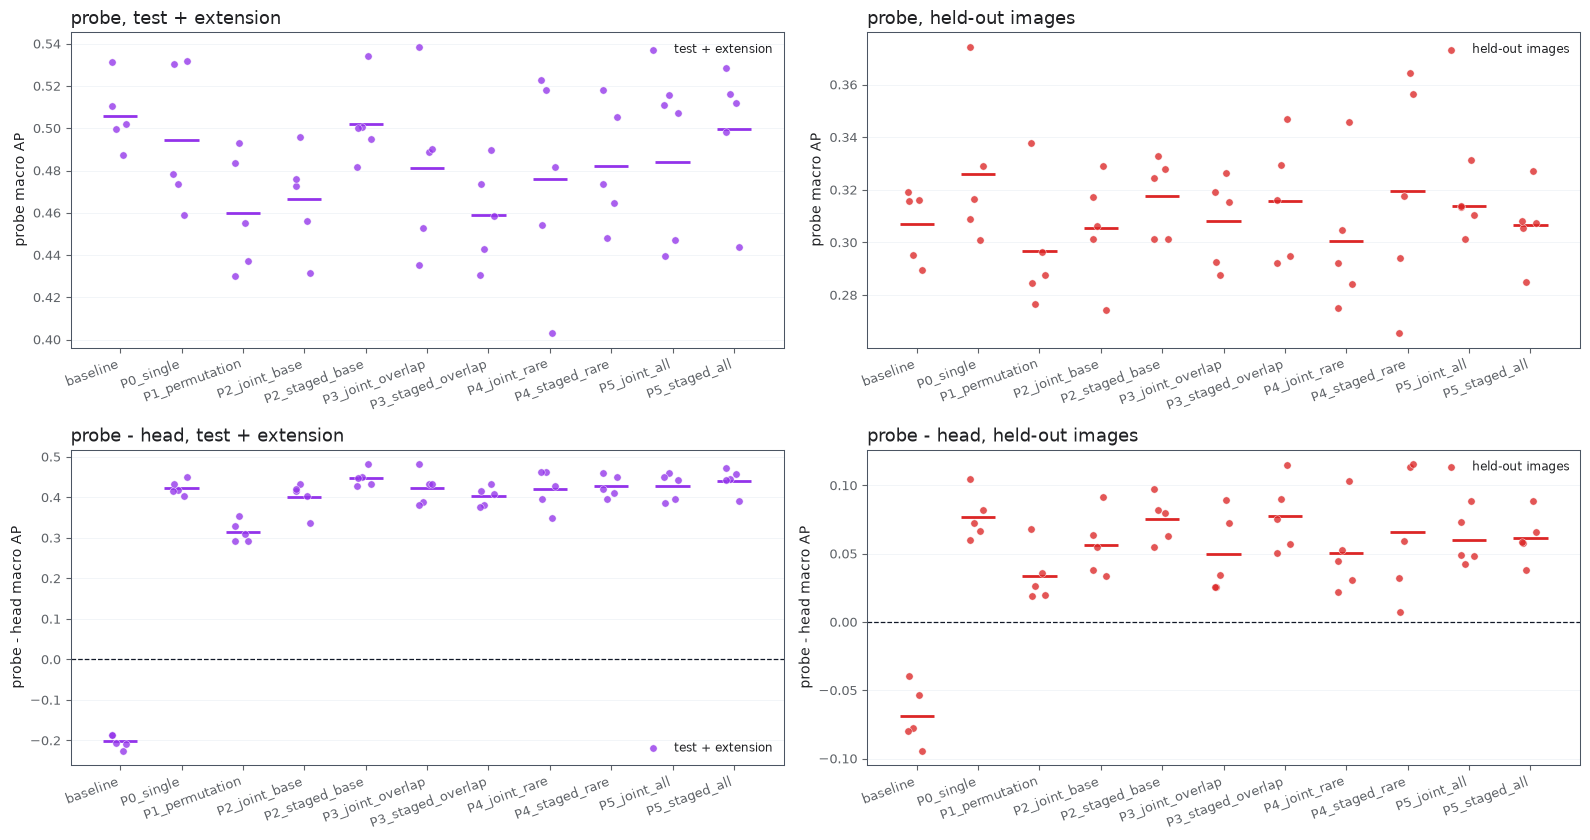

In [7]:
versus = table('probe_versus_head')
versus = versus[versus.metric == 'average_precision']
figure, axes = plt.subplots(2, 2, figsize=(16, 8.5), dpi=theme.figure_dpi)
for column, evaluation in enumerate(['test_combined', 'heldout_image']):
    rows = versus[versus.evaluation == evaluation].assign(kind=evaluation)
    figures.repetition_points(rows, value='value_probe', group='variant', hue='kind', order=ORDER, hue_order=[evaluation],
                              colors=POPULATION_COLORS, ylabel='probe macro AP', title=f'probe, {EVALUATION_NAMES[evaluation]}', ax=axes[0, column], theme=theme)
    figures.repetition_points(rows, value='probe_minus_head', group='variant', hue='kind', order=ORDER, hue_order=[evaluation],
                              colors=POPULATION_COLORS, ylabel='probe - head macro AP', title=f'probe - head, {EVALUATION_NAMES[evaluation]}',
                              reference=0.0, ax=axes[1, column], theme=theme)
figure.tight_layout()
display(versus.groupby(['variant', 'evaluation'])[['value_probe', 'value_head', 'probe_minus_head']].mean().unstack('evaluation').reindex(ORDER).round(4))

### Remarks

- test+ext: probe AP baseline 0.506, variants 0.459-0.502; probe - head baseline -0.202, variants 0.315 to 0.448.
- held-out: probe AP baseline 0.307, variants 0.297-0.326; probe - head baseline -0.069, variants 0.0339 to 0.0777.

### Notes

## Angular sensitivity to input perturbations

### Methodology

#### Theoretical

For relative input perturbations $\epsilon$ (multiplicative noise, then TIC renormalization) the mean
angle between the codes of the original and the perturbed spectrum (part 1_06). A representation that moves
less for small $\epsilon$ is more stable; at large $\epsilon$ the angle measures how much the code still
depends on the input.

#### Implementation

`sensitivity` (per model, population and $\epsilon$) averaged over repetitions here.

#### Figure descriptions

One panel per population; x = $\epsilon$ (log), y = mean angle in degrees, one line per variant.

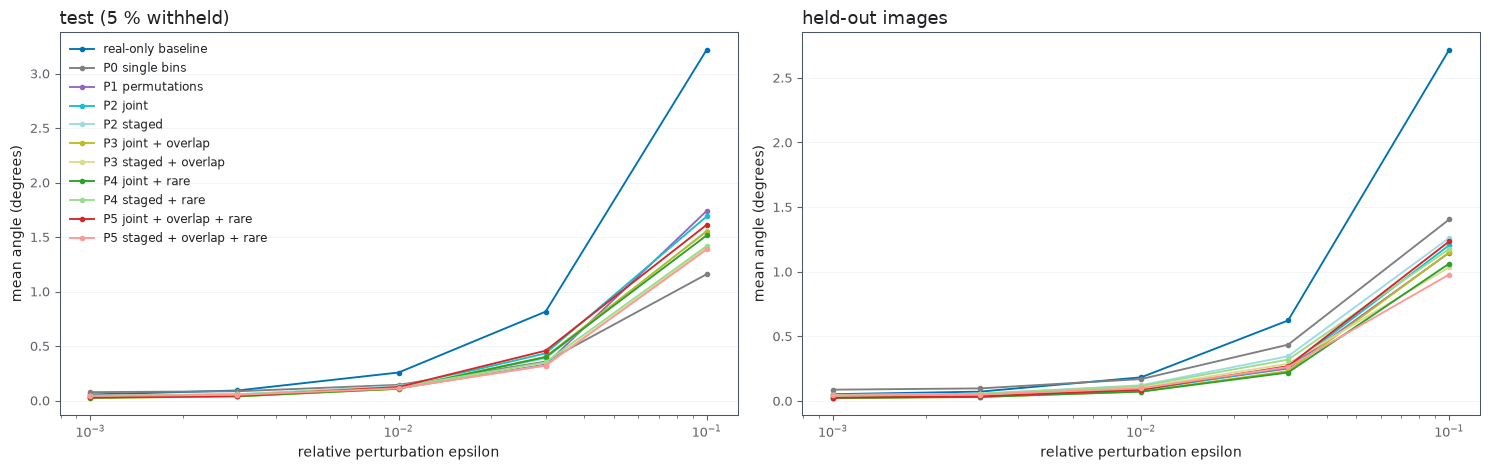

In [8]:
sensitivity = table('sensitivity').groupby(['variant', 'population', 'epsilon'], as_index=False).mean_angle_degrees.mean()
figure, axes = plt.subplots(1, 2, figsize=(15, 4.8), dpi=theme.figure_dpi)
for ax, population in zip(axes, ['test', 'heldout_image']):
    figures.epoch_curves(sensitivity[sensitivity.population == population], levels=ORDER, labels=VARIANT_LABELS, colors=VARIANT_COLORS,
                         x='epsilon', y='mean_angle_degrees', xlabel='relative perturbation epsilon', ylabel='mean angle (degrees)',
                         title=EVALUATION_NAMES[population], ax=ax, theme=theme)
    ax.set_xscale('log')
axes[1].get_legend().remove()
figure.tight_layout()

### Remarks

- Mean angle at epsilon 0.001 / 0.1 (test): baseline 0.056 / 3.22 degrees; variants 0.024-0.0774 / 1.16-1.74.

### Notes

## Covariance spectrum of the canonical codes

### Methodology

#### Theoretical

Eigenvalues of the covariance of $u$ normalized to sum 1: a flat spectrum uses every latent direction, a
steep one concentrates the variance in few directions (the effective rank summarizes it).

#### Implementation

`eigenvalues` (space $u$, test pixels), averaged over repetitions.

#### Figure descriptions

x = component index, y = variance share (log), one line per variant.

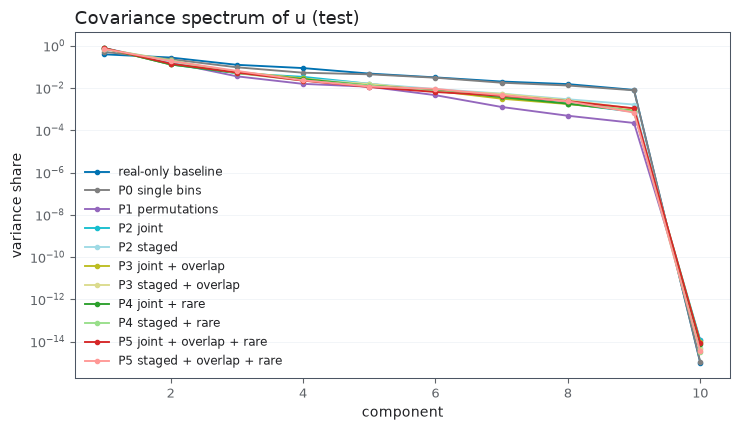

In [9]:
eigen = table('eigenvalues')
eigen = eigen[(eigen.space == 'u') & (eigen.population == 'test')].copy()
eigen['share'] = eigen.value / eigen.groupby('model_id').value.transform('sum')
eigen = eigen.groupby(['variant', 'component'], as_index=False).share.mean()
figures.epoch_curves(eigen, levels=ORDER, labels=VARIANT_LABELS, colors=VARIANT_COLORS, x='component', y='share', log_y=True,
                     xlabel='component', ylabel='variance share', title='Covariance spectrum of u (test)', theme=theme);

### Remarks

- Variance share of the first component: baseline 0.39, variants 0.51-0.772.

### Notes

## Results / Summary

### LLM

- **Observed:** probe macro AP (test + extension) baseline 0.506, variants 0.459-0.502; linear CKA to the baseline (test) 0.657-0.903.
- **Interpretation:** the pretrained representation already carries most of the linearly decodable annotation information of the baseline representation, although it was never trained on real annotations; the synthetic head cannot read it (probe - head strongly positive).

**Absolute levels against the real-only baseline** (means over repetitions; 'better' compares means only, without a test; the intervals are in the improvement sections):

- linear probe macro AP, test_combined: baseline 0.506; others 0.459-0.5022; 0 of 10 better than the baseline; best P2 staged (0.5022), worst P3 staged + overlap (0.459).
- linear probe macro AP, heldout_image: baseline 0.3071; others 0.2966-0.3259; 6 of 10 better than the baseline; best P0 single bins (0.3259), worst P1 permutations (0.2966).
- effective_rank, held-out: baseline 1.904; others 1.375-2.294; 1 of 10 better than the baseline; best P0 single bins (2.294), worst P1 permutations (1.375).
- knn_annotation_jaccard, held-out: baseline 0.6515; others 0.5723-0.6254; 0 of 10 better than the baseline; best P0 single bins (0.6254), worst P1 permutations (0.5723).

### Person